Columnas detectadas: ['observation_date', 'PCOCOUSDM']
✅ ¡Éxito! Serie cargada con 135 observaciones.


C:\Users\User\anaconda3\Lib\site-packages\pandas\core\indexes\base.py:7654: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)


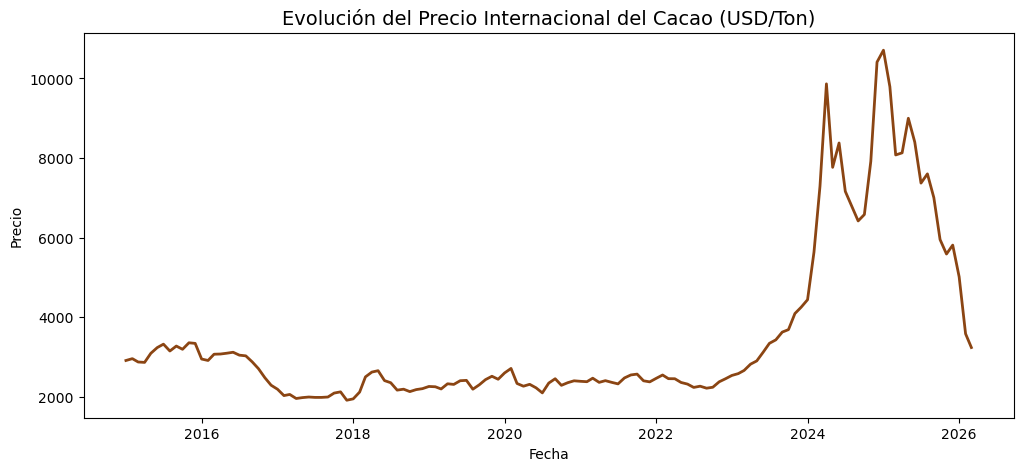

P-valor de la prueba de Dickey-Fuller: 0.0056


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 1. Rutas relativas (Requisito 8.a de las instrucciones)
BASE_DIR = Path.cwd().parent
DATA_PATH = BASE_DIR / "data" / "PCOCOUSDM.csv"

# 2. Carga y limpieza automática
try:
    # Leemos el archivo y vemos qué columnas tiene
    df = pd.read_csv(DATA_PATH)
    print(f"Columnas detectadas: {df.columns.tolist()}")
    
    # Buscamos la columna de fecha (que suele ser la primera) y la de precio
    df.columns = [col.upper() for col in df.columns] # Pasamos todo a mayúsculas para evitar errores
    
    if 'DATE' in df.columns:
        df['DATE'] = pd.to_datetime(df['DATE'])
        df.set_index('DATE', inplace=True)
    else:
        # Si no se llama DATE, asumimos que la primera columna es la fecha
        df.iloc[:, 0] = pd.to_datetime(df.iloc[:, 0])
        df.set_index(df.columns[0], inplace=True)

    # El precio es la columna PCOCOUSDM
    serie = df['PCOCOUSDM'].dropna()
    print(f"✅ ¡Éxito! Serie cargada con {len(serie)} observaciones.")

    # 3. Gráfica para el póster (Punto 10)
    plt.figure(figsize=(12, 5))
    sns.lineplot(data=serie, color='saddlebrown', linewidth=2)
    plt.title("Evolución del Precio Internacional del Cacao (USD/Ton)", fontsize=14)
    plt.ylabel("Precio")
    plt.xlabel("Fecha")
    plt.show()

    # 4. Prueba de Dickey-Fuller
    result = adfuller(serie)
    print(f'P-valor de la prueba de Dickey-Fuller: {result[1]:.4f}')

except Exception as e:
    print(f"❌ Error persistente: {e}")

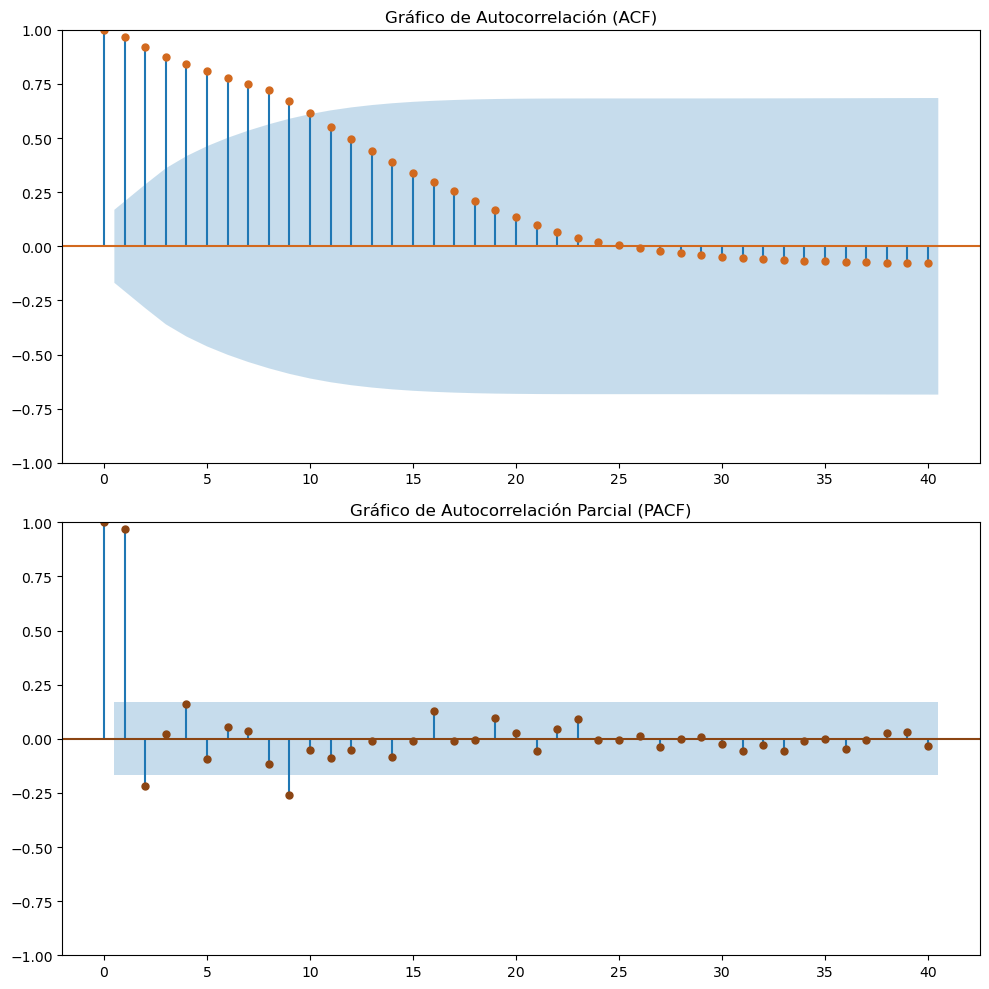

In [3]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Configuración de los correlogramas
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# Autocorrelación (ACF) - Ayuda a identificar el término MA(q)
plot_acf(serie, lags=40, ax=ax1, color='chocolate')
ax1.set_title('Gráfico de Autocorrelación (ACF)')

# Autocorrelación Parcial (PACF) - Ayuda a identificar el término AR(p)
plot_pacf(serie, lags=40, ax=ax2, color='saddlebrown')
ax2.set_title('Gráfico de Autocorrelación Parcial (PACF)')

plt.tight_layout()
plt.show()

In [4]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Estimación del modelo ARIMA(1, 0, 0) - Basado en nuestra identificación manual
# Usamos SARIMAX como recomienda la guía del curso
modelo = SARIMAX(serie, order=(1, 0, 0), trend='c')
resultado = modelo.fit()

# Resumen del modelo para el póster
print(resultado.summary())

C:\Users\User\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\User\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:              PCOCOUSDM   No. Observations:                  135
Model:               SARIMAX(1, 0, 0)   Log Likelihood               -1038.376
Date:                Thu, 21 May 2026   AIC                           2082.752
Time:                        23:15:59   BIC                           2091.467
Sample:                    01-01-2015   HQIC                          2086.293
                         - 03-01-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    129.6799    192.832      0.673      0.501    -248.264     507.623
ar.L1          0.9616      0.025     38.528      0.000       0.913       1.011
sigma2      2.755e+05   1.53e+04     17.983      0.0

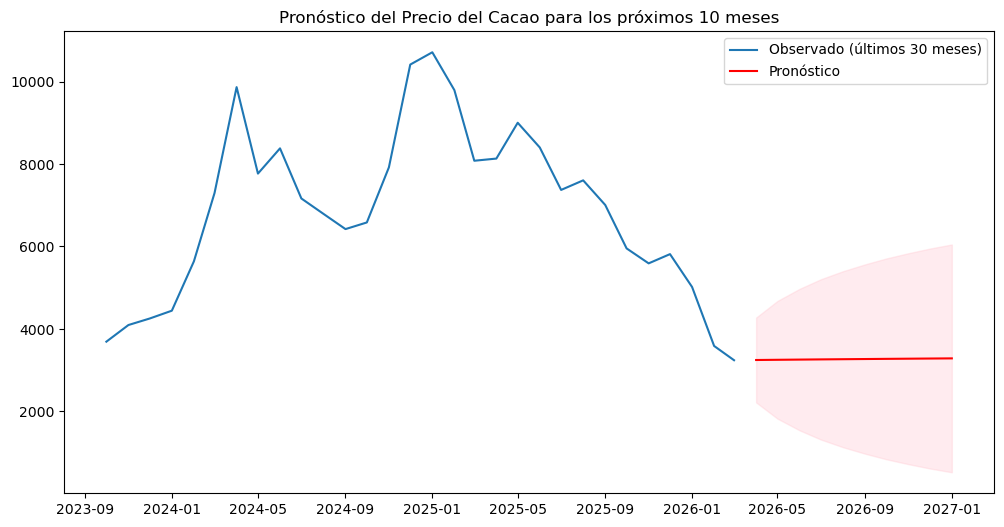

Valores pronosticados:
2026-04-01    3246.790602
2026-05-01    3251.888825
2026-06-01    3256.791425
2026-07-01    3261.505908
2026-08-01    3266.039494
2026-09-01    3270.399122
2026-10-01    3274.591469
2026-11-01    3278.622952
2026-12-01    3282.499744
2027-01-01    3286.227781
Freq: MS, Name: predicted_mean, dtype: float64


In [5]:
# Pronóstico para 10 periodos adelante (Punto 4 de Box-Jenkins)
forecast_steps = 10
prediccion = resultado.get_forecast(steps=forecast_steps)
pred_ci = prediccion.conf_int() # Intervalos de confianza

# Gráfica de pronóstico para el póster
plt.figure(figsize=(12, 6))
plt.plot(serie.index[-30:], serie.tail(30), label='Observado (últimos 30 meses)')
plt.plot(prediccion.predicted_mean.index, prediccion.predicted_mean, color='red', label='Pronóstico')
plt.fill_between(pred_ci.index, pred_ci.iloc[:, 0], pred_ci.iloc[:, 1], color='pink', alpha=0.3)
plt.title("Pronóstico del Precio del Cacao para los próximos 10 meses")
plt.legend()
plt.show()

print("Valores pronosticados:")
print(prediccion.predicted_mean)

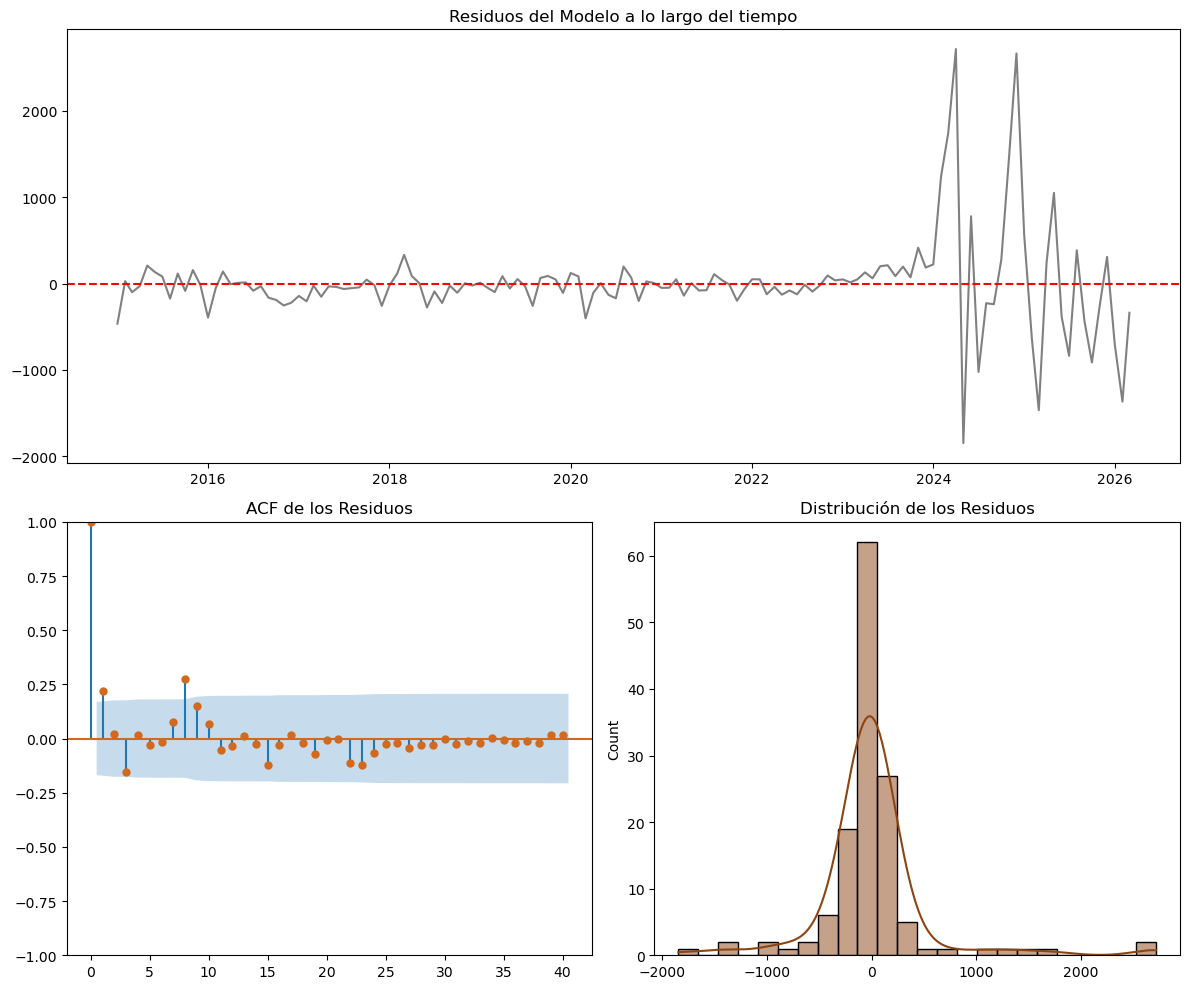

Prueba de Ljung-Box (Si p-value > 0.05, es Ruido Blanco):
     lb_stat  lb_pvalue
10  26.19717   0.003484


In [6]:
import statsmodels.api as sm

# 1. Obtener los residuales del modelo
residuales = resultado.resid

# 2. Crear una figura con 3 subgráficas para el póster
fig = plt.figure(figsize=(12, 10))
layout = (2, 2)
ts_ax = plt.subplot2grid(layout, (0, 0), colspan=2)
acf_ax = plt.subplot2grid(layout, (1, 0))
dist_ax = plt.subplot2grid(layout, (1, 1))

# Gráfica 1: Residuales en el tiempo (¿Se ven aleatorios?)
ts_ax.plot(residuales, color='gray')
ts_ax.set_title('Residuos del Modelo a lo largo del tiempo')
ts_ax.axhline(0, color='red', linestyle='--')

# Gráfica 2: ACF de los residuos (¿Hay información restante?)
sm.graphics.tsa.plot_acf(residuales, lags=40, ax=acf_ax, color='chocolate')
acf_ax.set_title('ACF de los Residuos')

# Gráfica 3: Distribución de residuos (¿Es normal?)
sns.histplot(residuales, kde=True, ax=dist_ax, color='saddlebrown')
dist_ax.set_title('Distribución de los Residuos')

plt.tight_layout()
plt.show()

# 3. Prueba formal de Ljung-Box (Ruido Blanco)
lb_test = sm.stats.acorr_ljungbox(residuales, lags=[10], return_df=True)
print("Prueba de Ljung-Box (Si p-value > 0.05, es Ruido Blanco):")
print(lb_test)

✅ ¡Imágenes guardadas! Búscalas en el panel de la izquierda.


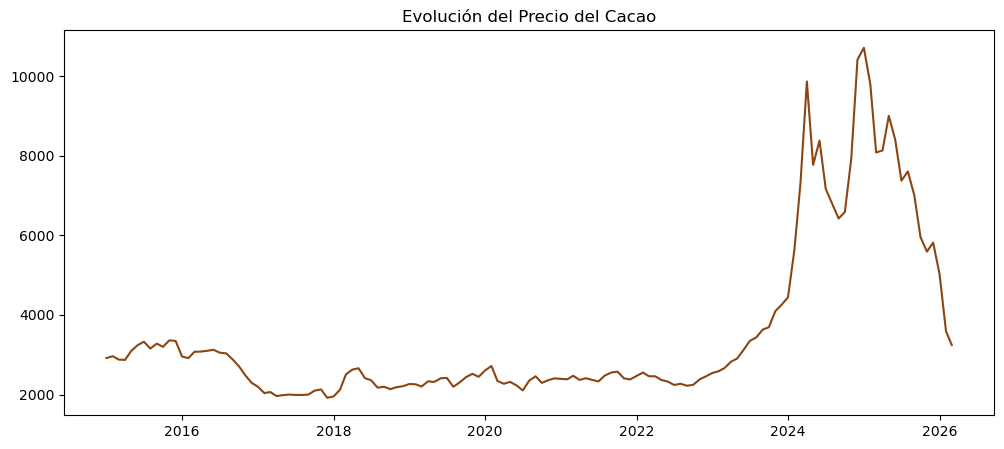

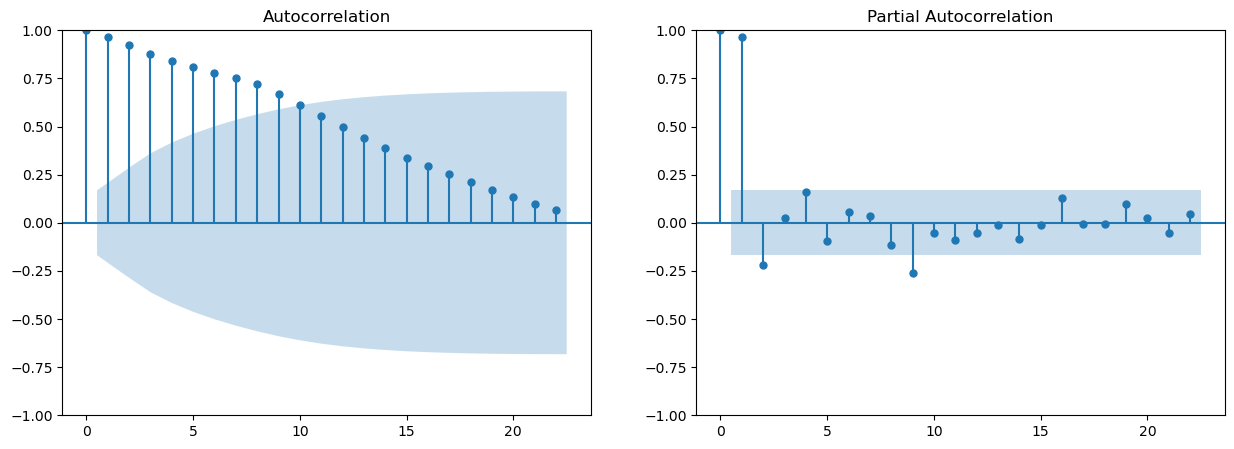

In [7]:
# Guardar las gráficas principales con alta resolución (300 DPI)
# Nota: Debes haber corrido los códigos anteriores para que las variables existan

# 1. Serie Original
plt.figure(figsize=(12, 5))
plt.plot(serie, color='saddlebrown')
plt.title("Evolución del Precio del Cacao")
plt.savefig('01_serie_original.png', dpi=300, bbox_inches='tight')

# 2. Correlogramas
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
plot_acf(serie, ax=ax[0])
plot_pacf(serie, ax=ax[1])
plt.savefig('02_correlogramas.png', dpi=300, bbox_inches='tight')

# 3. Pronóstico
# (Usa el código que ya tienes pero añade esta línea al final)
plt.savefig('03_pronostico_final.png', dpi=300, bbox_inches='tight')

print("✅ ¡Imágenes guardadas! Búscalas en el panel de la izquierda.")